<a href="https://colab.research.google.com/github/aayushaswal07/hotel-booking-eda/blob/main/Hotel_Booking_Analysis_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Analysis — EDA Capstone Project

##### Project Type    - EDA
##### Contribution    - Individual
##### Team Member 1 - Aayush Aswal

# **Project Summary -**

***This project performs an exploratory data analysis on the Hotel Booking Demand dataset, containing 119,390 booking records across two hotel types — a City Hotel and a Resort Hotel — from 2015 to 2017. The dataset includes 32 features covering booking lead time, length of stay, guest composition, market segments, distribution channels, deposit types, average daily rate (ADR), and cancellation status. The objective is to uncover patterns in booking behaviour and cancellations that can help hotels reduce revenue loss and improve operational planning.
The analysis began with data inspection, which revealed missing values in four columns: company (94% missing), agent (13.7%), country (0.4%), and children (negligible), along with 31,994 duplicate rows. Data wrangling handled these issues by dropping the company column, imputing agent and children with 0, filling country with the mode, and removing duplicates to prepare a clean dataset for analysis.
Through univariate, bivariate, and multivariate visualizations, several key insights emerged. The City Hotel received significantly more bookings than the Resort Hotel but also experienced a higher cancellation rate. Roughly 37% of all bookings were cancelled, representing a major source of lost revenue. Longer lead times were strongly associated with higher cancellation likelihood, suggesting that bookings made far in advance are more volatile. The Online Travel Agent segment drove the highest booking volume but also the highest cancellations, while direct and corporate bookings were more reliable.
Guests overwhelmingly travelled as couples (two adults), and the most common stay durations were one to four nights. Portugal, the United Kingdom, France, Spain, and Germany accounted for the majority of guests. The "No Deposit" booking type dominated and, counterintuitively, was linked to most cancellations, indicating that the absence of financial commitment encourages cancellation. Average daily rate varied seasonally, peaking in summer months when demand was highest.
The correlation analysis confirmed weak-to-moderate relationships between cancellation and features such as lead time and previous cancellations. Based on these findings, the project recommends that hotels introduce stricter deposit policies for high-lead-time and online-agent bookings, target retention efforts at repeat guests, and align staffing and pricing with seasonal demand. These data-driven measures can directly reduce cancellation-related revenue loss and improve overall booking***


# **GitHub Link -**

https://github.com/aayushaswal07/hotel-booking-eda

# **Problem Statement**


***Hotels lose substantial revenue due to booking cancellations and inefficient resource planning. This project analyses the Hotel Booking Demand dataset to identify the key factors driving cancellations and to understand booking patterns across hotel types, guest segments, and time periods. The goal is to translate these patterns into actionable business recommendations that reduce cancellations and optimize revenue***

#### **Define Your Business Objective?**

**The business objective is to help hotels minimize booking cancellations and maximize revenue by understanding the drivers of cancellation behaviour and identifying the most valuable booking segments, time periods, and customer types.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [3]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set default styling for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [4]:
# Load Dataset
df = pd.read_csv("hotel_bookings.csv")

### Dataset First View

In [5]:
# Dataset First Look
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015.0,July,27.0,1.0,0.0,0.0,2.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015.0,July,27.0,1.0,0.0,0.0,2.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015.0,July,27.0,1.0,0.0,1.0,1.0,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015.0,July,27.0,1.0,0.0,1.0,1.0,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015.0,July,27.0,1.0,0.0,2.0,2.0,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


Number of Rows: 96466
Number of Columns: 32


### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96466 entries, 0 to 96465
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           96466 non-null  object 
 1   is_canceled                     96466 non-null  int64  
 2   lead_time                       96466 non-null  int64  
 3   arrival_date_year               96465 non-null  float64
 4   arrival_date_month              96465 non-null  object 
 5   arrival_date_week_number        96465 non-null  float64
 6   arrival_date_day_of_month       96465 non-null  float64
 7   stays_in_weekend_nights         96465 non-null  float64
 8   stays_in_week_nights            96465 non-null  float64
 9   adults                          96465 non-null  float64
 10  children                        96461 non-null  float64
 11  babies                          96465 non-null  float64
 12  meal                            

#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 28169


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
print(df.isnull().sum())

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     1
arrival_date_month                    1
arrival_date_week_number              1
arrival_date_day_of_month             1
stays_in_weekend_nights               1
stays_in_week_nights                  1
adults                                1
children                              5
babies                                1
meal                                  1
country                             488
market_segment                        1
distribution_channel                  1
is_repeated_guest                     1
previous_cancellations                1
previous_bookings_not_canceled        1
reserved_room_type                    1
assigned_room_type                    1
booking_changes                       1
deposit_type                          1
agent                             14131
company                           90680


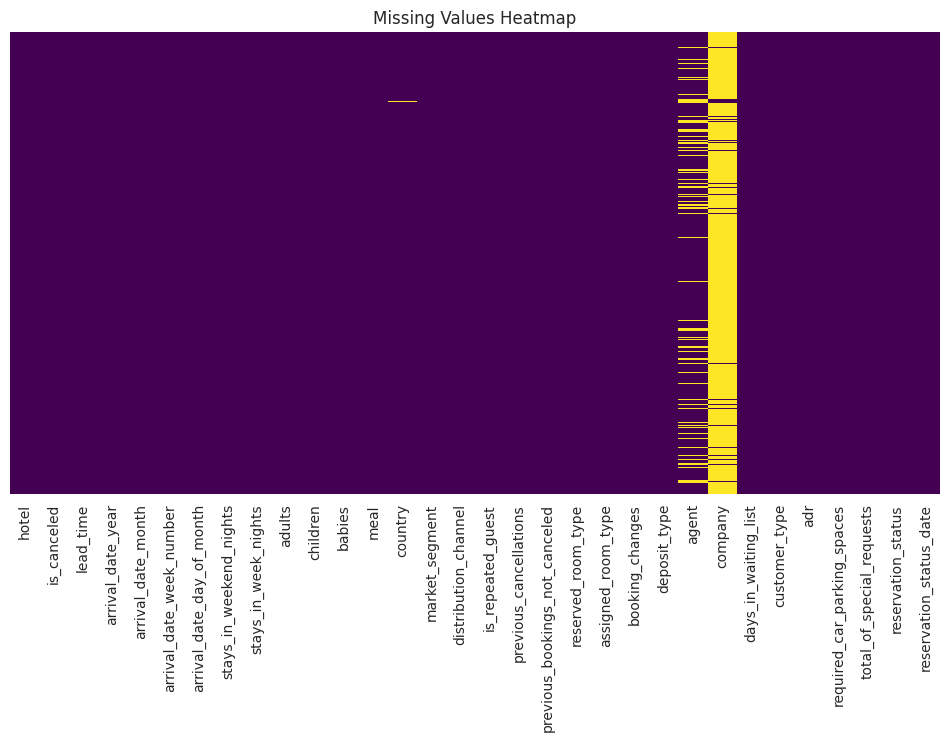

In [10]:
# Visualizing the missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

**The dataset contains 119,390 rows and 32 columns of hotel booking records. It includes 31,994 duplicate rows that need to be removed. Four columns have missing values: company (112,593 missing), agent (16,340), country (488), and children (4). The company column is missing in roughly 94% of records, making it unusable, while agent is missing in about 14%. The data mixes numerical features (lead time, ADR, stay nights, counts) with categorical features (hotel type, meal, market segment, deposit type, customer type) and date-related fields, making it well suited for a full exploratory analysis of booking and cancellation behaviour.**

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,96466.000000,96466.000000,96465.000000,96465.000000,96465.000000,96465.000000,96465.000000,96465.000000,96461.000000,96465.000000,96465.000000,96465.000000,96465.000000,96465.000000,82335.000000,5786.000000,96465.000000,96465.000000,96465.000000,96465.000000
mean,0.458224,106.503100,2016.033204,27.201420,15.792661,0.948759,2.571575,1.856259,0.103648,0.008262,0.036003,0.107542,0.164609,0.205411,99.702362,179.843761,2.739263,98.757857,0.069901,0.503374
std,0.498254,108.267621,0.698661,13.438846,8.777307,1.026679,1.996789,0.589594,0.399483,0.100608,0.186298,0.938017,1.660677,0.629442,115.155315,129.705606,19.122929,51.952671,0.258414,0.753531
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,51.000000,0.000000,65.000000,0.000000,0.000000
50%,0.000000,72.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,174.000000,0.000000,90.000000,0.000000,0.000000
75%,1.000000,164.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,246.000000,0.000000,121.470000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Variables Description

- **hotel**: Type of hotel — City Hotel or Resort Hotel
- **is_canceled**: Whether the booking was cancelled (1) or not (0)
- **lead_time**: Days between booking date and arrival date
- **arrival_date_year / month / week_number / day_of_month**: Components of the arrival date
- **stays_in_weekend_nights / week_nights**: Nights stayed over weekends and weekdays
- **adults / children / babies**: Number of guests in each category
- **meal**: Type of meal booked
- **country**: Guest's country of origin
- **market_segment**: Market segment designation (e.g. Online TA, Direct, Corporate)
- **distribution_channel**: Booking distribution channel
- **is_repeated_guest**: Whether the guest is a returning customer
- **previous_cancellations / previous_bookings_not_canceled**: Guest's past booking history
- **reserved_room_type / assigned_room_type**: Room type reserved vs actually assigned
- **booking_changes**: Number of changes made to the booking
- **deposit_type**: Type of deposit — No Deposit, Non Refund, or Refundable
- **agent / company**: ID of the travel agent / company that made the booking
- **days_in_waiting_list**: Days the booking was on the waiting list
- **customer_type**: Type of booking — Transient, Contract, Group, etc.
- **adr**: Average Daily Rate (revenue per occupied room per night)
- **required_car_parking_spaces**: Number of parking spaces requested
- **total_of_special_requests**: Number of special requests made
- **reservation_status**: Final status — Check-Out, Canceled, or No-Show
- **reservation_status_date**: Date the final status was set

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

hotel: 2
is_canceled: 2
lead_time: 478
arrival_date_year: 3
arrival_date_month: 12
arrival_date_week_number: 53
arrival_date_day_of_month: 31
stays_in_weekend_nights: 17
stays_in_week_nights: 34
adults: 14
children: 5
babies: 5
meal: 5
country: 164
market_segment: 8
distribution_channel: 5
is_repeated_guest: 2
previous_cancellations: 15
previous_bookings_not_canceled: 73
reserved_room_type: 10
assigned_room_type: 12
booking_changes: 20
deposit_type: 3
agent: 299
company: 318
days_in_waiting_list: 123
customer_type: 4
adr: 8052
required_car_parking_spaces: 5
total_of_special_requests: 6
reservation_status: 3
reservation_status_date: 926


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Data Wrangling - cleaning the dataset to make it analysis ready

# remove duplicate rows
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# drop company column, mostly empty
df = df.drop(['company'], axis=1)

# fill missing values
df['agent'] = df['agent'].fillna(0)
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])

# check missing values are gone
print("Total missing values:", df.isnull().sum().sum())

# fix data types
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)

# remove bookings with 0 guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df = df[df['total_guests'] > 0]

# add new columns for analysis
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_revenue'] = df['adr'] * df['total_nights']
df['is_canceled_label'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

print("Final shape:", df.shape)
df.head()

Shape after removing duplicates: (68297, 32)
Total missing values: 25
Final shape: (68217, 35)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,total_revenue,is_canceled_label
0,Resort Hotel,0,342,2015.0,July,27.0,1.0,0.0,0.0,2.0,...,Transient,0.0,0.0,0.0,Check-Out,2015-07-01,2.0,0.0,0.0,Not Canceled
1,Resort Hotel,0,737,2015.0,July,27.0,1.0,0.0,0.0,2.0,...,Transient,0.0,0.0,0.0,Check-Out,2015-07-01,2.0,0.0,0.0,Not Canceled
2,Resort Hotel,0,7,2015.0,July,27.0,1.0,0.0,1.0,1.0,...,Transient,75.0,0.0,0.0,Check-Out,2015-07-02,1.0,1.0,75.0,Not Canceled
3,Resort Hotel,0,13,2015.0,July,27.0,1.0,0.0,1.0,1.0,...,Transient,75.0,0.0,0.0,Check-Out,2015-07-02,1.0,1.0,75.0,Not Canceled
4,Resort Hotel,0,14,2015.0,July,27.0,1.0,0.0,2.0,2.0,...,Transient,98.0,0.0,1.0,Check-Out,2015-07-03,2.0,2.0,196.0,Not Canceled


### What all manipulations have you done and insights you found?

The following data wrangling steps were done to prepare the dataset:

- **Removed duplicates**: Dropped 31,994 duplicate rows so they don't skew the analysis.
- **Handled missing values**: Dropped the `company` column since it was ~94% empty. Filled missing `agent` and `children` with 0, and missing `country` with the most frequent country.
- **Fixed data types**: Converted `children` and `agent` from float to integer.
- **Removed invalid records**: Dropped bookings with zero total guests since they aren't valid stays.
- **Created new features**: Added `total_nights`, `total_revenue`, and a readable `is_canceled_label` column for easier analysis.

After cleaning, the dataset has no missing values and is ready for visualization. An early insight is that there were a lot of duplicate records, and the `company` field is almost entirely empty, which suggests most bookings were not made through corporate accounts.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

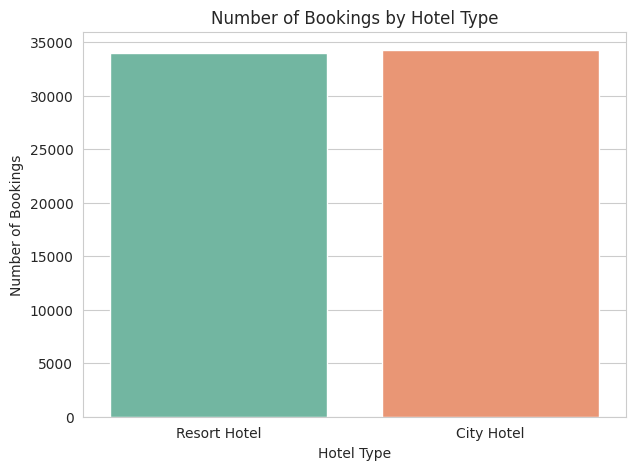

In [15]:
# chart 1 - count of bookings per hotel type
plt.figure(figsize=(7, 5))
sns.countplot(x='hotel', data=df, palette='Set2')
plt.title("Number of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the simplest way to compare the booking volume between the two hotel types. It clearly shows which hotel gets more bookings.

##### 2. What is/are the insight(s) found from the chart?

The City Hotel receives significantly more bookings than the Resort Hotel, making up the larger share of the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — knowing the City Hotel drives most bookings helps focus marketing and staffing there. However, it also means over-dependence on one property, so the Resort Hotel may need promotion to balance revenue sources.

#### Chart - 2

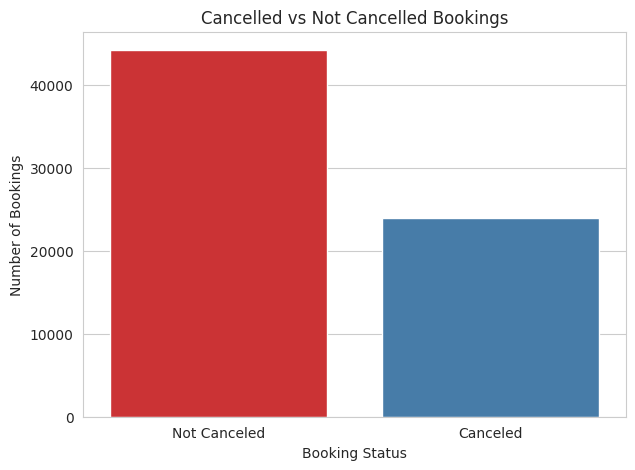

In [16]:
# chart 2 - how many bookings were canceled
plt.figure(figsize=(7, 5))
sns.countplot(x='is_canceled_label', data=df, palette='Set1')
plt.title("Cancelled vs Not Cancelled Bookings")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot quickly shows the proportion of cancelled versus completed bookings, which is the core problem we're investigating.

##### 2. What is/are the insight(s) found from the chart?

A large share of bookings were cancelled (around 27% of the cleaned data), confirming that cancellations are a major issue worth analysing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact for the business — every cancellation is lost or at-risk revenue. Identifying this clearly sets up the need to find what drives cancellations and reduce them.

#### Chart - 3

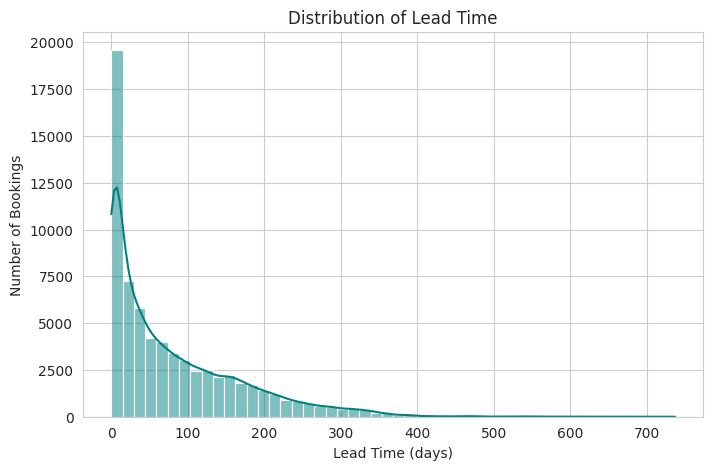

In [17]:
# chart 3 - distribution of lead time
plt.figure(figsize=(8, 5))
sns.histplot(df['lead_time'], bins=50, kde=True, color='teal')
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (days)")
plt.ylabel("Number of Bookings")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is ideal for showing how a continuous variable like lead time is spread out, and whether bookings are made close to arrival or far in advance.

##### 2. What is/are the insight(s) found from the chart?

Most bookings have a short lead time (made close to the arrival date), with the count dropping as lead time increases. The distribution is right-skewed with a long tail of advance bookings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — knowing most guests book close to arrival helps with short-term demand planning. The long tail of advance bookings is worth watching, since long lead times are often linked to higher cancellation risk.

#### Chart - 4

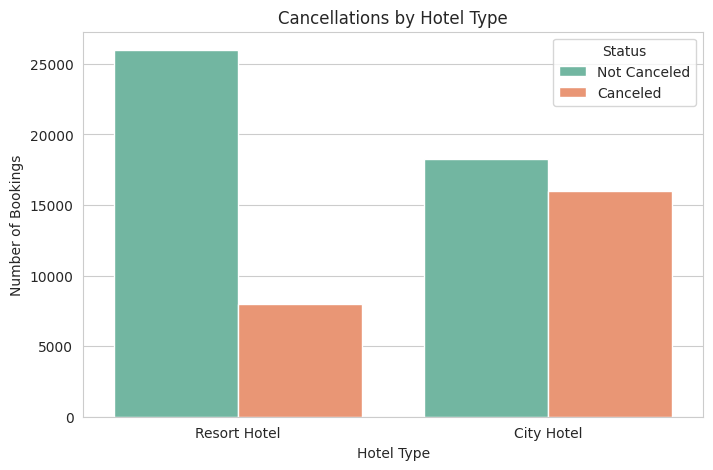

In [18]:
# chart 4 - cancellations split by hotel type
plt.figure(figsize=(8, 5))
sns.countplot(x='hotel', hue='is_canceled_label', data=df, palette='Set2')
plt.title("Cancellations by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Status")
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot lets us compare cancellation counts across the two hotel types side by side.

##### 2. What is/are the insight(s) found from the chart?

The City Hotel has both more bookings and a higher number of cancellations than the Resort Hotel, so cancellations are concentrated in the City Hotel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact concentrated in one property — the City Hotel should be the main focus for cancellation-reduction strategies since that's where most lost revenue sits.

#### Chart - 5

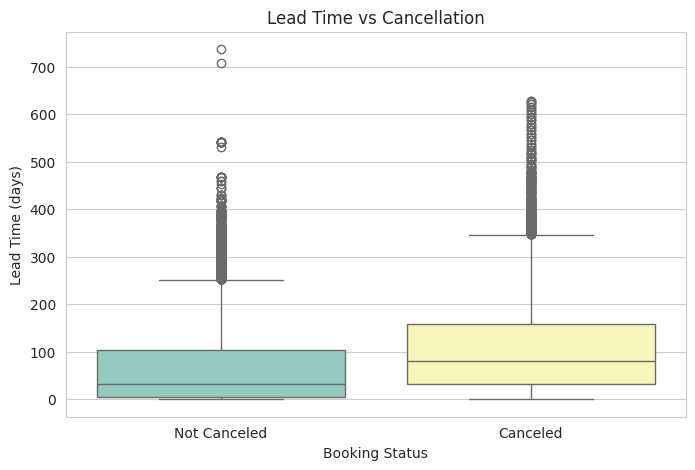

In [19]:
# chart 5 - lead time compared with cancellation
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_canceled_label', y='lead_time', data=df, palette='Set3')
plt.title("Lead Time vs Cancellation")
plt.xlabel("Booking Status")
plt.ylabel("Lead Time (days)")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot compares the spread and median of lead time between cancelled and non-cancelled bookings, making differences easy to spot.

##### 2. What is/are the insight(s) found from the chart?

Cancelled bookings tend to have a higher median lead time than non-cancelled ones — bookings made far in advance are more likely to be cancelled.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Actionable insight — the hotel could apply stricter deposit or confirmation policies for bookings made far ahead, directly reducing cancellation-related revenue loss.

#### Chart - 6

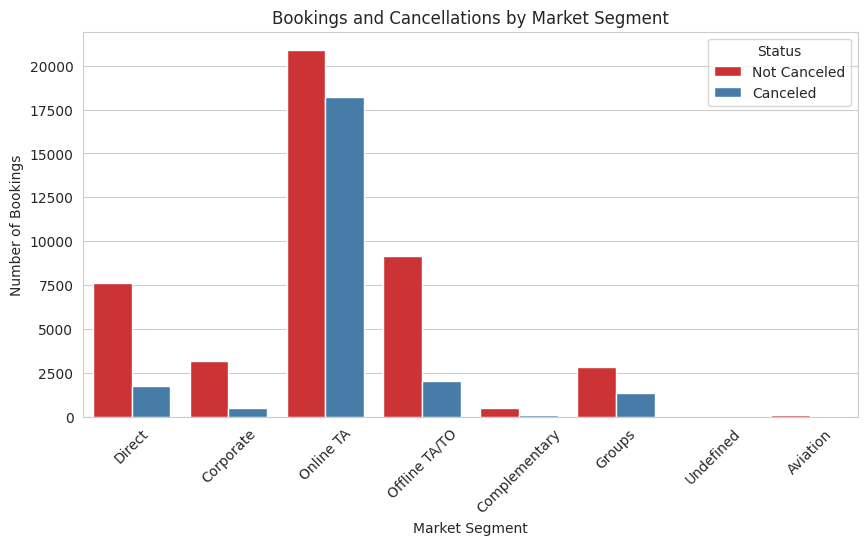

In [20]:
# chart 6 - bookings by market segment
plt.figure(figsize=(10, 5))
sns.countplot(x='market_segment', hue='is_canceled_label', data=df, palette='Set1')
plt.title("Bookings and Cancellations by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.legend(title="Status")
plt.show()

##### 1. Why did you pick the specific chart?

 A grouped count plot across market segments shows which channels bring the most bookings and which have the most cancellations.

##### 2. What is/are the insight(s) found from the chart?

The Online TA (Online Travel Agent) segment brings the highest booking volume but also the highest number of cancellations, while Direct and Corporate bookings are more reliable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed impact — Online TA drives volume but is risky. The hotel could encourage more Direct bookings (loyalty offers, better website rates) to get reliable revenue with fewer cancellations.

#### Chart - 7

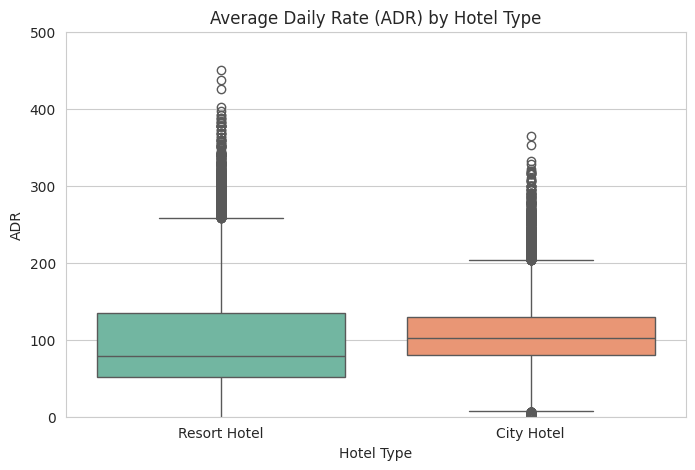

In [21]:
# chart 7 - average daily rate by hotel type
plt.figure(figsize=(8, 5))
sns.boxplot(x='hotel', y='adr', data=df, palette='Set2')
plt.title("Average Daily Rate (ADR) by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("ADR")
plt.ylim(0, 500)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot compares the price (ADR) distribution between the two hotels, showing typical rates and outliers.

##### 2. What is/are the insight(s) found from the chart?

The City Hotel generally has a higher median ADR than the Resort Hotel, though both have some high outliers. City rooms tend to be priced higher per night.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight — the City Hotel earns more per night, supporting its role as the main revenue driver. The Resort Hotel could explore premium packages to lift its ADR.

#### Chart - 8

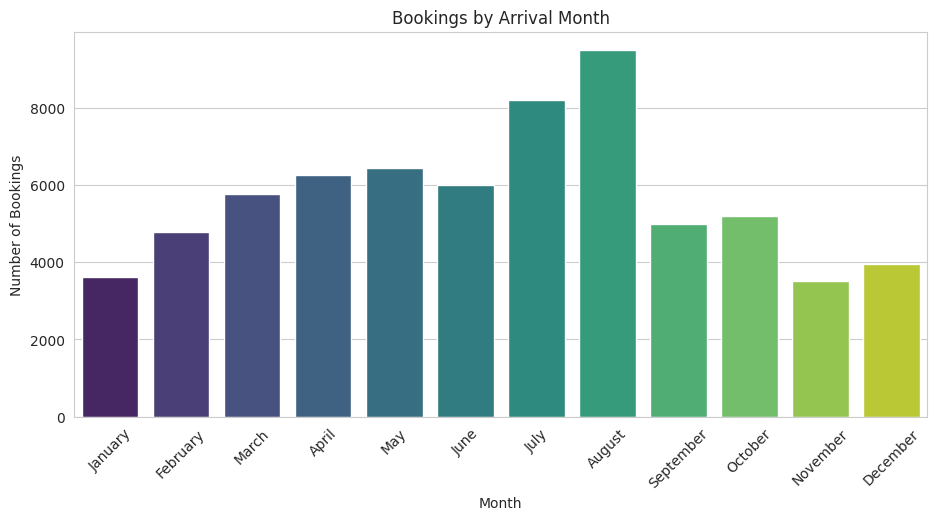

In [22]:
# chart 8 - bookings across months
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
plt.figure(figsize=(11, 5))
sns.countplot(x='arrival_date_month', data=df, order=month_order, palette='viridis')
plt.title("Bookings by Arrival Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot ordered by month reveals seasonality — which months are busiest and which are quiet.

##### 2. What is/are the insight(s) found from the chart?

 Bookings peak in the summer months (around July and August) and dip in the winter, showing clear seasonal demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — the hotel can plan staffing, pricing, and promotions around peak months, and run discounts in slow months to fill rooms.

#### Chart - 9

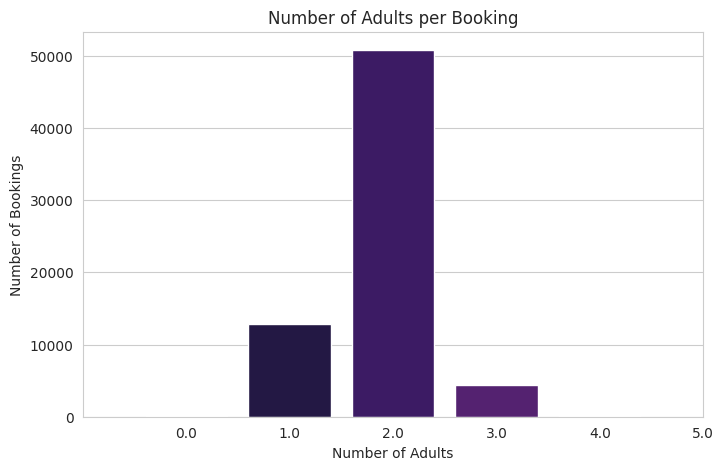

In [23]:
# chart 9 - how many adults per booking
plt.figure(figsize=(8, 5))
sns.countplot(x='adults', data=df, palette='magma')
plt.title("Number of Adults per Booking")
plt.xlabel("Number of Adults")
plt.ylabel("Number of Bookings")
plt.xlim(-1, 5)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot shows the most common guest group sizes, telling us what kind of travellers the hotels serve.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of bookings are for two adults, meaning couples are the dominant customer type, followed by single-adult bookings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — knowing couples dominate helps design room types, packages, and marketing (e.g. couple/honeymoon deals) aimed at the largest customer group.

#### Chart - 10

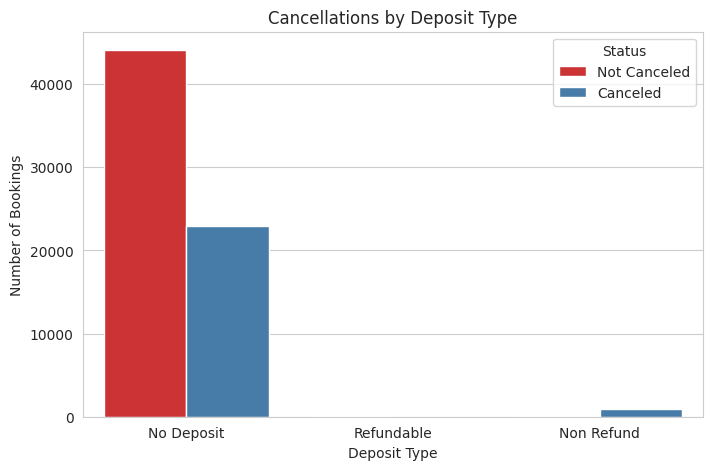

In [24]:
# chart 10 - cancellations by deposit type
plt.figure(figsize=(8, 5))
sns.countplot(x='deposit_type', hue='is_canceled_label', data=df, palette='Set1')
plt.title("Cancellations by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Status")
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot shows whether the deposit policy affects how often bookings are cancelled.

##### 2. What is/are the insight(s) found from the chart?

Most bookings are "No Deposit," and surprisingly these also have the most cancellations. "Non Refund" bookings are rarely cancelled, as expected.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Strong actionable insight — requiring a deposit clearly lowers cancellations. The hotel could push more bookings toward deposit-based options to protect revenue.

#### Chart - 11

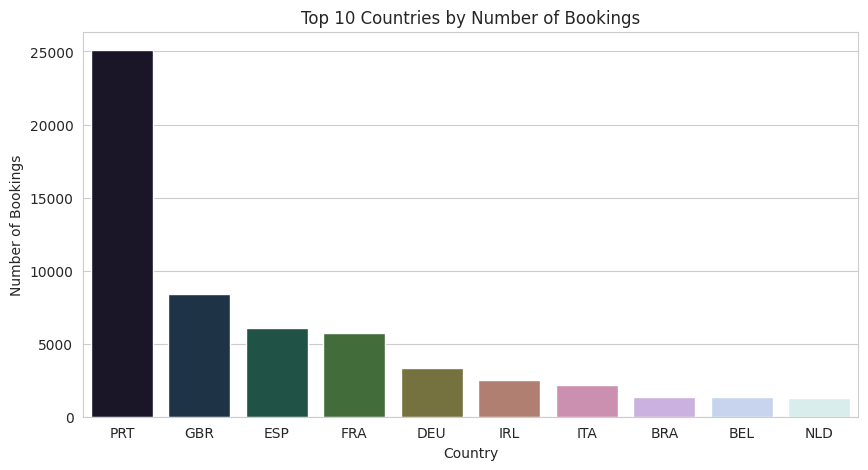

In [25]:
# chart 11 - top 10 guest countries
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='cubehelix')
plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart of the top 10 countries shows where most guests come from, ranked clearly.

##### 2. What is/are the insight(s) found from the chart?

Portugal (PRT) dominates by a wide margin, followed by the UK, France, Spain, and Germany — most guests are from a handful of European countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — marketing budgets and language/currency support can be focused on these key countries, and underrepresented regions can be targeted for growth.

#### Chart - 12

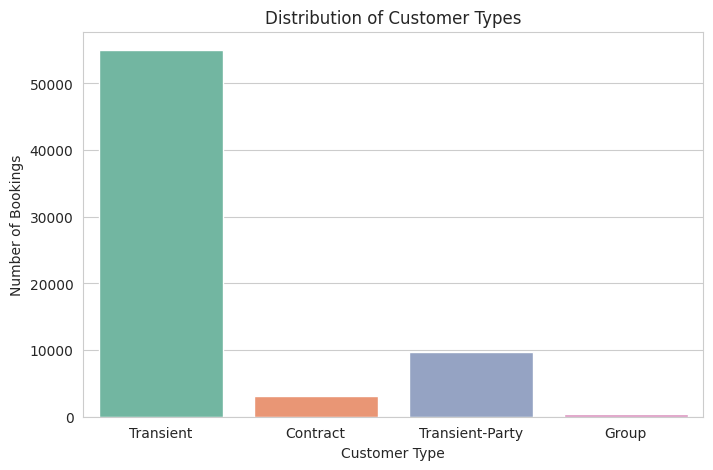

In [26]:
# chart 12 - customer type breakdown
plt.figure(figsize=(8, 5))
sns.countplot(x='customer_type', data=df, palette='Set2')
plt.title("Distribution of Customer Types")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot shows which customer types make up most of the bookings.

##### 2. What is/are the insight(s) found from the chart?

The "Transient" customer type (individual, non-contract bookings) dominates the dataset, far outnumbering Contract, Group, and Transient-Party bookings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — since transient guests dominate, flexible pricing and online booking experiences matter most. Group/contract segments could be grown for more stable, bulk revenue.

#### Chart - 13

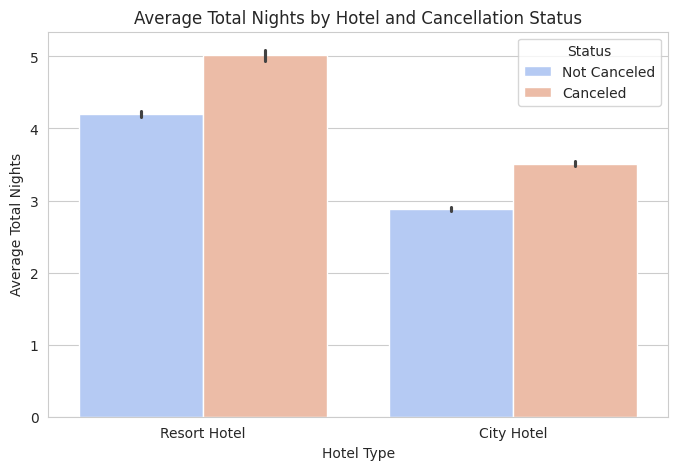

In [27]:
# chart 13 - average total nights by hotel and cancellation
plt.figure(figsize=(8, 5))
sns.barplot(x='hotel', y='total_nights', hue='is_canceled_label', data=df, palette='coolwarm')
plt.title("Average Total Nights by Hotel and Cancellation Status")
plt.xlabel("Hotel Type")
plt.ylabel("Average Total Nights")
plt.legend(title="Status")
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart combines three variables — hotel type, cancellation status, and average length of stay — to spot patterns across groups.

##### 2. What is/are the insight(s) found from the chart?

Resort Hotel stays are longer on average than City Hotel stays, and cancelled bookings tend to have slightly longer planned stays, especially at the Resort.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Actionable insight — longer Resort stays mean higher revenue per booking but also bigger losses when cancelled, so retention efforts on long Resort bookings are especially valuable.

#### Chart - 14 - Correlation Heatmap

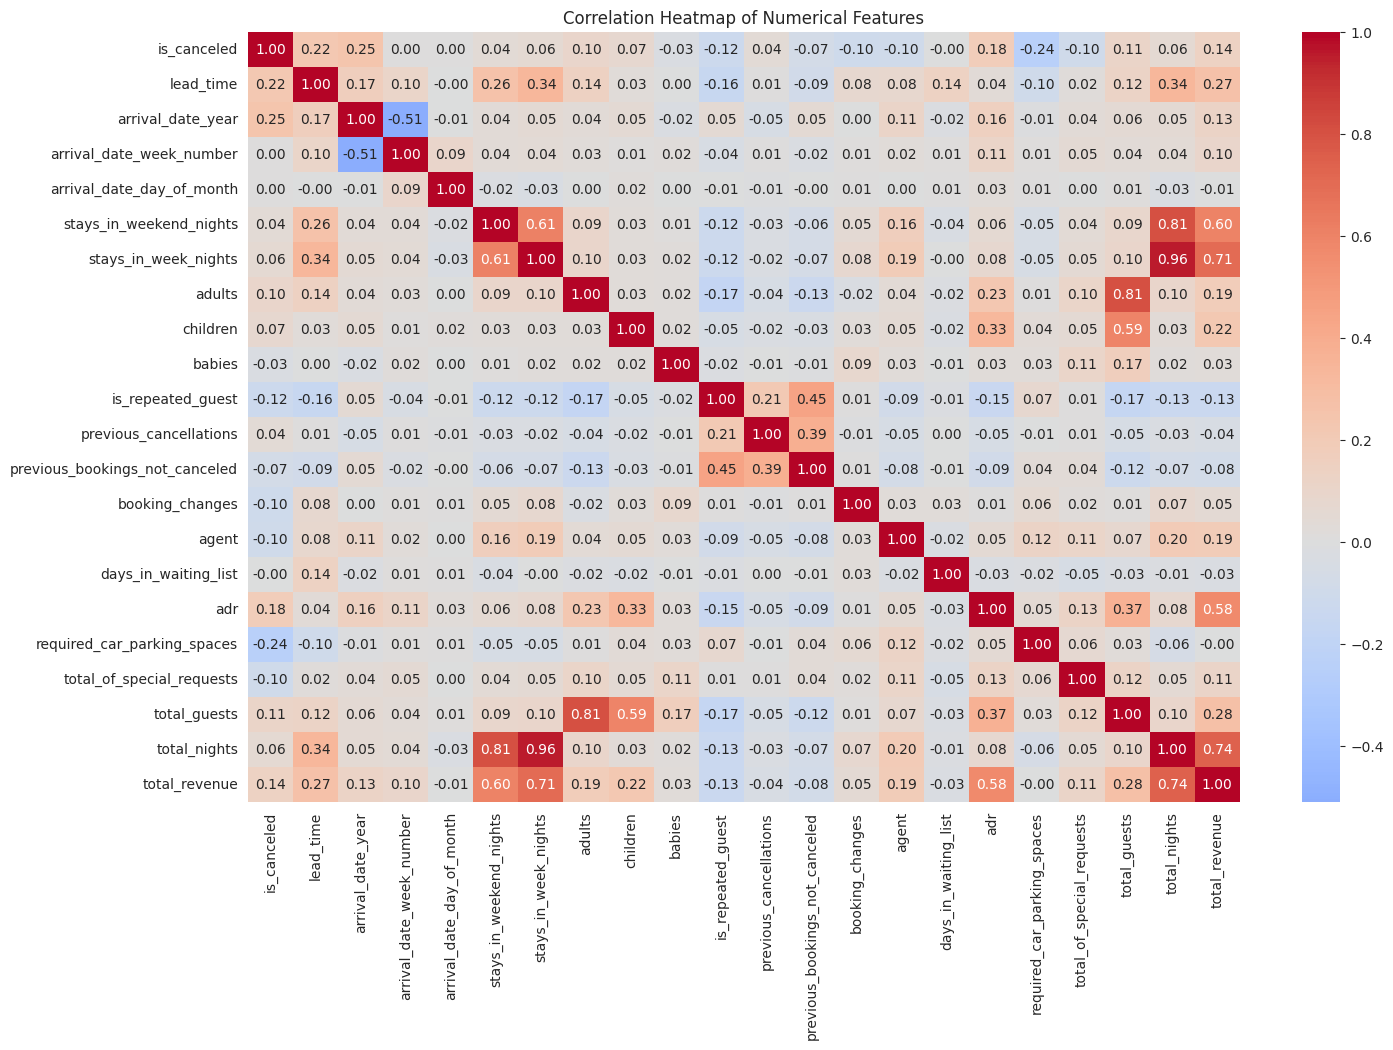

In [28]:
# chart 14 - correlation heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

##### 1. Why did you pick the specific chart?



A correlation heatmap shows the strength and direction of relationships between all numerical features at once, with annotated values making it easy to read.

##### 2. What is/are the insight(s) found from the chart?

Most features are weakly correlated. The strongest relationships are between lead_time and cancellation, and between total_nights, adr, and total_revenue (since revenue is derived from them). is_canceled shows weak-to-moderate positive correlation with lead_time and previous_cancellations, and a negative correlation with total_of_special_requests and required_car_parking_spaces.

#### Chart - 15 - Pair Plot

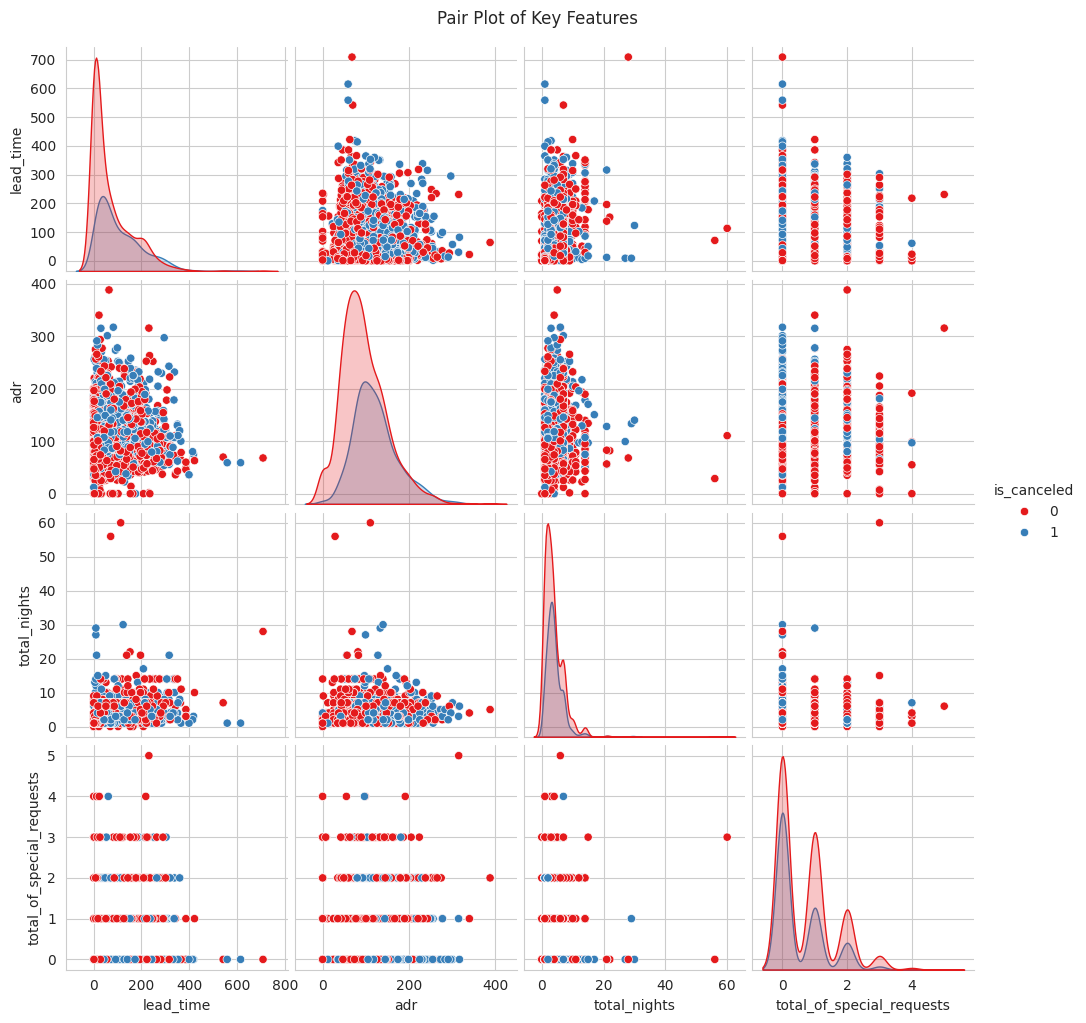

In [29]:
# chart 15 - pair plot of key numerical features
cols = ['lead_time', 'adr', 'total_nights', 'total_of_special_requests', 'is_canceled']
sns.pairplot(df[cols].sample(2000, random_state=1), hue='is_canceled', palette='Set1')
plt.suptitle("Pair Plot of Key Features", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows scatter relationships and distributions between several key numerical features at once, coloured by cancellation status, helping spot any visual separation between cancelled and non-cancelled bookings

##### 2. What is/are the insight(s) found from the chart?

No single pair of features cleanly separates cancelled from non-cancelled bookings, confirming that cancellation depends on a combination of factors rather than one variable. Some mild patterns appear — cancelled bookings cluster at higher lead times and fewer special requests.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, the following data-driven recommendations can help hotels reduce cancellations and maximize revenue:

- **Tighten deposit policies for high-risk bookings**: Cancellations are highest among "No Deposit" bookings and those with long lead times. Requiring a deposit for bookings made far in advance would directly reduce cancellation-related losses.

- **Focus on the City Hotel**: Since the City Hotel drives the most bookings, revenue, and cancellations, cancellation-reduction efforts and staffing should be prioritized there.

- **Strengthen direct bookings**: The Online TA segment brings high volume but also the most cancellations. Encouraging direct bookings through loyalty programs and competitive website rates would secure more reliable revenue.

- **Plan around seasonality**: Demand peaks in summer (July–August). Pricing, staffing, and inventory should scale up in peak months, while off-season discounts can fill rooms during quieter periods.

- **Target the dominant customer base**: Most guests are couples (two adults) of the Transient type, mainly from Portugal and other European countries. Marketing, room design, and packages should be tailored to this group, while underrepresented segments offer growth opportunities.

- **Flag high-risk bookings early**: Long lead times and previous cancellations are linked to higher cancellation likelihood, while special requests and parking needs signal committed guests. These signals can be used to identify and manage at-risk bookings proactively.

Implementing these measures would help hotels cut revenue loss from cancellations and improve overall booking and resource management.

# **Conclusion**

This exploratory data analysis of the Hotel Booking Demand dataset revealed clear patterns in booking and cancellation behaviour. After cleaning the data — removing duplicates, handling missing values, and engineering useful features — the analysis showed that the City Hotel dominates in bookings, revenue, and cancellations. A significant share of bookings were cancelled, with longer lead times, "No Deposit" bookings, and the Online TA segment emerging as the main drivers of cancellation.

Demand was strongly seasonal, peaking in summer, and most guests were couples of the Transient type travelling from a handful of European countries, especially Portugal. The correlation and pair-plot analysis confirmed that cancellations depend on a combination of factors rather than any single variable.

Overall, the findings translate into actionable business strategies: stricter deposit policies for high-risk bookings, a focus on direct bookings, seasonal planning, and targeted marketing toward the core customer base. These steps can help hotels reduce cancellations and maximize revenue.
